In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

print('All imports successful!!')

All imports successful!!


# Load Data and First Look

In [3]:
df = pd.read_csv("/content/bangalore_delivery_data.csv")

In [4]:
print("Shape:", df.shape)

Shape: (17280, 8)


In [6]:
print("Column names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Column names: ['zone_id', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_raining', 'base_zone_demand', 'prev_hour_orders', 'actual_orders']

Data Types:
zone_id             object
hour_of_day          int64
day_of_week          int64
is_weekend           int64
is_raining           int64
base_zone_demand     int64
prev_hour_orders     int64
actual_orders        int64
dtype: object

First 5 rows:


,zone_id,hour_of_day,day_of_week,is_weekend,is_raining,base_zone_demand,prev_hour_orders,actual_orders
0,koramangala,0,0,0,0,18,2,3
1,indiranagar,0,0,0,0,15,2,2
2,whitefield,0,0,0,0,12,2,2
3,marathahalli,0,0,0,0,14,2,4
4,hsr_layout,0,0,0,0,13,2,1


# Check for missing Values and Basic Statistics

In [7]:
print("Missing Values per column:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Missing Values per column:
zone_id             0
hour_of_day         0
day_of_week         0
is_weekend          0
is_raining          0
base_zone_demand    0
prev_hour_orders    0
actual_orders       0
dtype: int64

Basic Statistics:


,hour_of_day,day_of_week,is_weekend,is_raining,base_zone_demand,prev_hour_orders,actual_orders
count,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000
mean,11.500000,2.966667,0.277778,0.211111,12.750000,13.552315,13.121701
std,6.922387,1.985840,0.447916,0.408109,2.727257,10.049310,10.069195
min,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000
25%,5.750000,1.000000,0.000000,0.000000,10.750000,6.000000,5.000000
50%,11.500000,3.000000,0.000000,0.000000,12.500000,12.000000,11.000000
75%,17.250000,5.000000,1.000000,0.000000,14.250000,19.000000,19.000000
max,23.000000,6.000000,1.000000,1.000000,18.000000,74.000000,71.000000


# Visualisation 1: Hourly demand pattern

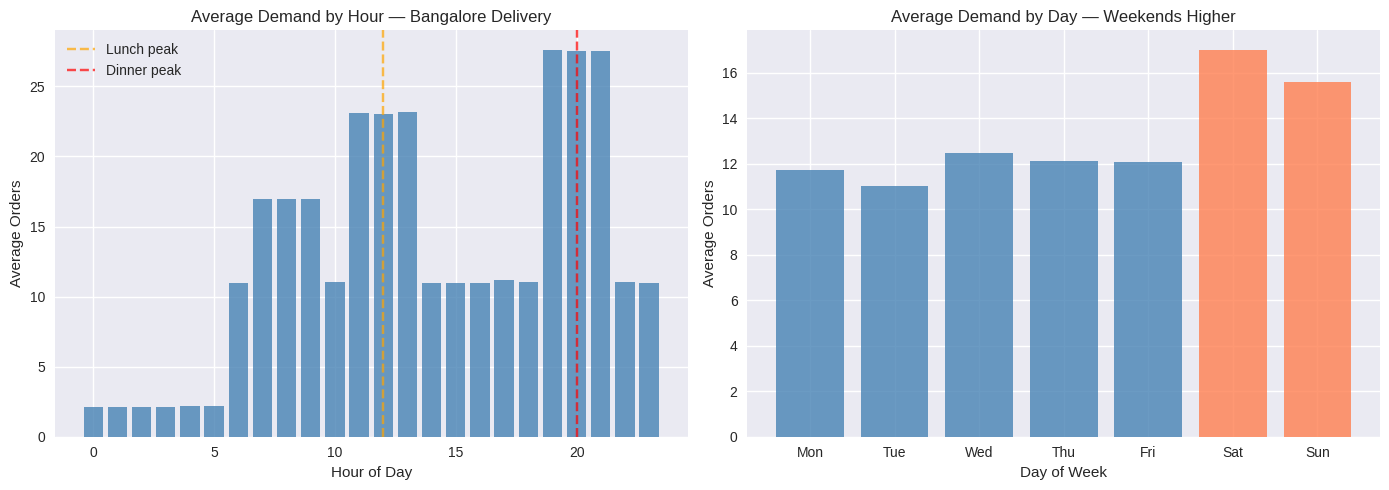

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_avg = df.groupby('hour_of_day')['actual_orders'].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Orders')
axes[0].set_title('Average Demand by Hour — Bangalore Delivery')
axes[0].axvline(x=12, color='orange', linestyle='--', alpha=0.7, label='Lunch peak')
axes[0].axvline(x=20, color='red', linestyle='--', alpha=0.7, label='Dinner peak')
axes[0].legend()

daily_avg = df.groupby('day_of_week')['actual_orders'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = ['steelblue'] * 5 + ['coral', 'coral']
axes[1].bar(day_names, daily_avg.values, color=colors, alpha=0.8)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Orders')
axes[1].set_title('Average Demand by Day — Weekends Higher')

plt.tight_layout()
plt.savefig('/content/demand_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualisation 2: Rain effect and zone comparison

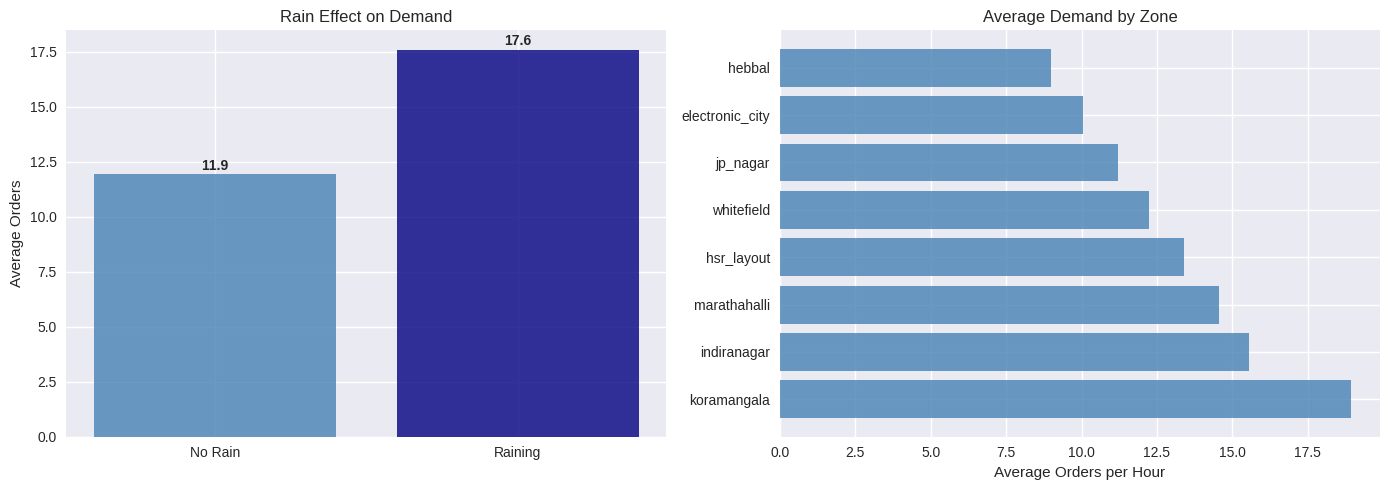

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rain_comparison = df.groupby('is_raining')['actual_orders'].mean()
axes[0].bar(['No Rain', 'Raining'], rain_comparison.values,
            color=['steelblue', 'navy'], alpha=0.8)
axes[0].set_ylabel('Average Orders')
axes[0].set_title('Rain Effect on Demand')
for i, v in enumerate(rain_comparison.values):
    axes[0].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

zone_avg = df.groupby('zone_id')['actual_orders'].mean().sort_values(ascending=False)
axes[1].barh(zone_avg.index, zone_avg.values, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Average Orders per Hour')
axes[1].set_title('Average Demand by Zone')

plt.tight_layout()
plt.savefig('/content/zone_rain_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Engineering

In [12]:
df_model = df.copy()

le = LabelEncoder()
df_model['zone_encoded'] = le.fit_transform(df_model['zone_id'])

print("Zone encoding:")
for zone, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {zone} → {code}")

df_model['is_lunch_hour'] = ((df_model['hour_of_day'] >= 11) &
                              (df_model['hour_of_day'] <= 13)).astype(int)

df_model['is_dinner_hour'] = ((df_model['hour_of_day'] >= 19) &
                               (df_model['hour_of_day'] <= 21)).astype(int)

df_model['is_breakfast_hour'] = ((df_model['hour_of_day'] >= 7) &
                                  (df_model['hour_of_day'] <= 9)).astype(int)

df_model['is_late_night'] = (df_model['hour_of_day'] <= 5).astype(int)

df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour_of_day'] / 24)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour_of_day'] / 24)

df_model['rain_weekend'] = df_model['is_raining'] * df_model['is_weekend']

print("\nNew features added:")
print(df_model.columns.tolist())
print(f"\nDataset shape after feature engineering: {df_model.shape}")

Zone encoding:
  electronic_city → 0
  hebbal → 1
  hsr_layout → 2
  indiranagar → 3
  jp_nagar → 4
  koramangala → 5
  marathahalli → 6
  whitefield → 7

New features added:
['zone_id', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_raining', 'base_zone_demand', 'prev_hour_orders', 'actual_orders', 'zone_encoded', 'is_lunch_hour', 'is_dinner_hour', 'is_breakfast_hour', 'is_late_night', 'hour_sin', 'hour_cos', 'rain_weekend']

Dataset shape after feature engineering: (17280, 16)


# Prepare features and split data

In [13]:
FEATURES = [
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_raining',
    'base_zone_demand', 'prev_hour_orders', 'zone_encoded',
    'is_lunch_hour', 'is_dinner_hour', 'is_breakfast_hour',
    'is_late_night', 'hour_sin', 'hour_cos', 'rain_weekend'
]

TARGET = 'actual_orders'

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"\nFeatures used: {FEATURES}")

Training set: 13824 rows
Test set:     3456 rows

Features used: ['hour_of_day', 'day_of_week', 'is_weekend', 'is_raining', 'base_zone_demand', 'prev_hour_orders', 'zone_encoded', 'is_lunch_hour', 'is_dinner_hour', 'is_breakfast_hour', 'is_late_night', 'hour_sin', 'hour_cos', 'rain_weekend']


#Train and compare three models

In [14]:
def evaluate_model(name, model, X_test, X_train, y_test, y_train):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  print(f"\n{name}")
  print(f"  MAE: {mae:.2f}")
  print(f"  RMSE: {rmse:.2f}")
  print(f"  R2: {r2:.2f}")

  return model,y_pred, {"name": name, "MAE": mae, "RMSE": rmse, "R2": r2}

print("Training and Evaluating models...")
print("=" * 50)

lr_model, lr_pred, lr_scores = evaluate_model(
    "Linear Regression (baseline)",
    LinearRegression(),
    X_test, X_train, y_test, y_train
)

rf_model, rf_pred, rf_scores = evaluate_model(
    "Random Forest",
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_test, X_train, y_test, y_train
)

xgb_model, xgb_pred, xgb_scores = evaluate_model(
    "XGBoost",
    xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mae'
    ),
    X_train, X_test, y_train, y_test
)

Training and Evaluating models...

Linear Regression (baseline)
  MAE: 2.03
  RMSE: 2.66
  R2: 0.93

Random Forest
  MAE: 1.91
  RMSE: 2.50
  R2: 0.94

XGBoost
  MAE: 1.86
  RMSE: 2.47
  R2: 0.94


#Compare results visually

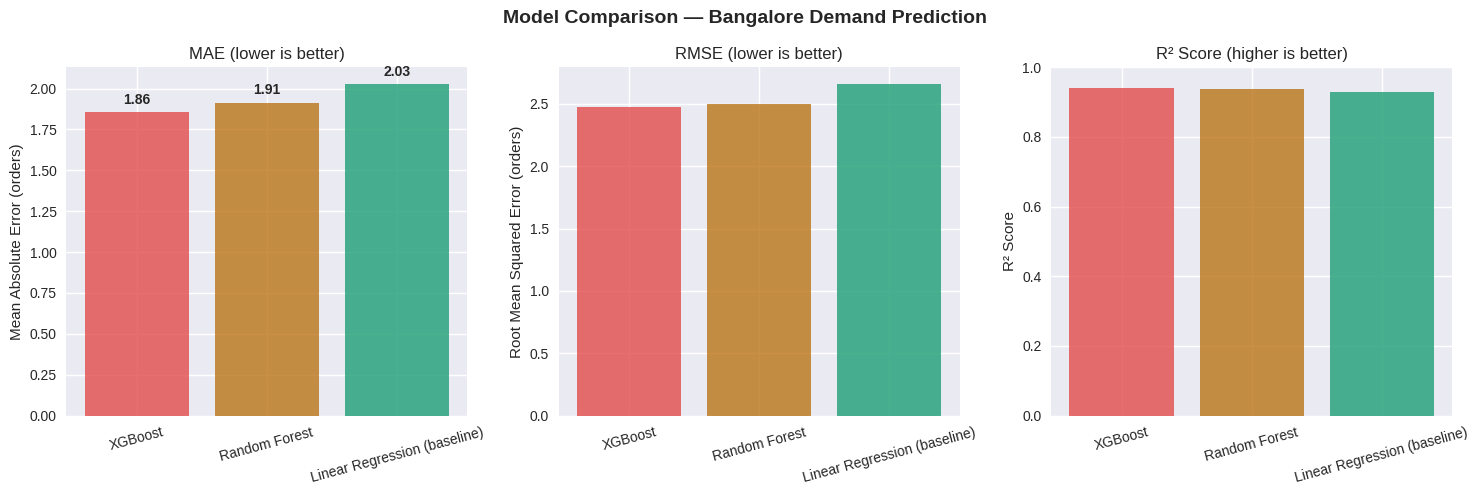


Best model: XGBoost
Best MAE: 1.86 orders


In [16]:
results = pd.DataFrame([lr_scores, rf_scores, xgb_scores])
results = results.sort_values('MAE')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#E24B4A', '#BA7517', '#1D9E75']

axes[0].bar(results['name'], results['MAE'], color=colors, alpha=0.8)
axes[0].set_title('MAE (lower is better)')
axes[0].set_ylabel('Mean Absolute Error (orders)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(results['MAE']):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

axes[1].bar(results['name'], results['RMSE'], color=colors, alpha=0.8)
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('Root Mean Squared Error (orders)')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(results['name'], results['R2'], color=colors, alpha=0.8)
axes[2].set_title('R² Score (higher is better)')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison — Bangalore Demand Prediction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBest model:", results.iloc[0]['name'])
print(f"Best MAE: {results.iloc[0]['MAE']:.2f} orders")

#SHAP values

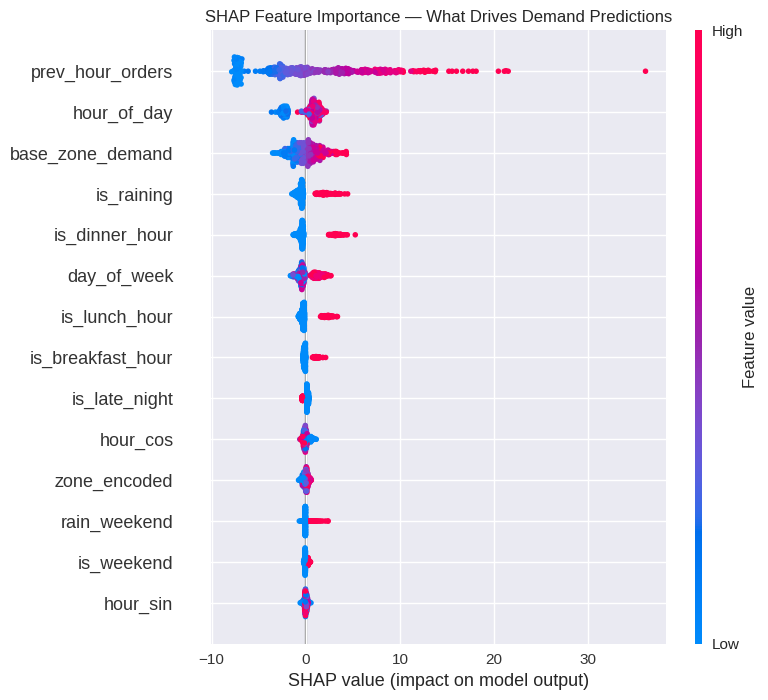


Top 5 most important features:
          feature  importance
 prev_hour_orders    5.150563
      hour_of_day    1.267745
 base_zone_demand    1.165077
       is_raining    0.887555
   is_dinner_hour    0.866029
      day_of_week    0.772177
    is_lunch_hour    0.625516
is_breakfast_hour    0.262367
    is_late_night    0.221629
         hour_cos    0.198318


In [17]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:500])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:500],
                  feature_names=FEATURES,
                  show=False)
plt.title('SHAP Feature Importance — What Drives Demand Predictions')
plt.tight_layout()
plt.savefig('/content/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': mean_shap
}).sort_values('importance', ascending=False)
print(feature_importance.head(10).to_string(index=False))

# Save the Model

In [19]:
import pickle
import json

with open('/content/models/xgboost_demand_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('/content/models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

model_metadata = {
    "model_type": "XGBoost Regressor",
    "features": FEATURES,
    "zones": le.classes_.tolist(),
    "metrics": {
        "MAE": float(xgb_scores['MAE']),
        "RMSE": float(xgb_scores['RMSE']),
        "R2": float(xgb_scores['R2'])
    },
    "training_rows": int(X_train.shape[0]),
    "test_rows": int(X_test.shape[0])
}

with open('/content/models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("Model saved successfully")
print(f"\nModel metadata:")
print(json.dumps(model_metadata, indent=2))

Model saved successfully

Model metadata:
{
  "model_type": "XGBoost Regressor",
  "features": [
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "is_raining",
    "base_zone_demand",
    "prev_hour_orders",
    "zone_encoded",
    "is_lunch_hour",
    "is_dinner_hour",
    "is_breakfast_hour",
    "is_late_night",
    "hour_sin",
    "hour_cos",
    "rain_weekend"
  ],
  "zones": [
    "electronic_city",
    "hebbal",
    "hsr_layout",
    "indiranagar",
    "jp_nagar",
    "koramangala",
    "marathahalli",
    "whitefield"
  ],
  "metrics": {
    "MAE": 1.8576288223266602,
    "RMSE": 2.474816413775145,
    "R2": 0.9396254420280457
  },
  "training_rows": 13824,
  "test_rows": 3456
}
